# Principal Component Analysis (PCA) — From-Scratch Implementation & Demo

This notebook has two parts:

**Part A — From-Scratch Implementation:** We implement PCA manually using NumPy (standardize → covariance matrix → eigenvectors/eigenvalues → project), and verify it matches scikit-learn's `PCA` exactly.

**Part B — Demos:**
1. Naive projection vs PCA projection on 2D synthetic data (matches the "Size vs Rooms" example from the notes)
2. PCA on the classic Iris dataset (4D → 2D visualization)
3. Explained variance / scree plot — deciding how many components to keep
4. Image compression / reconstruction demo using PCA on the Digits dataset



## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

np.random.seed(42)
plt.rcParams["figure.facecolor"] = "white"


---
# Part A — From-Scratch PCA Implementation

Following the exact algorithm from the notes:
1. Standardize the data (zero-center, unit variance)
2. Compute the covariance matrix
3. Compute eigenvectors & eigenvalues of the covariance matrix
4. Sort eigenvectors by eigenvalue (descending)
5. Keep the top K eigenvectors as principal components
6. Project the original data onto them


In [2]:
class PCAFromScratch:
    """A from-scratch implementation of PCA, following the standard algorithm."""

    def __init__(self, n_components):
        # Number of Principal Components (PCs) we want to keep.
        # Example: n_components=2 means we keep PC1 and PC2.
        self.n_components = n_components

        # Mean of each feature.
        # It will be calculated inside fit().
        self.mean_ = None

        # Standard deviation of each feature.
        # It will be calculated inside fit().
        self.std_ = None

        # The top-K eigenvectors.
        # These eigenvectors become our Principal Components.
        self.components_ = None

        # The top-K eigenvalues.
        # Eigenvalues tell us how much variance each
        # Principal Component captures.
        self.explained_variance_ = None

        # Percentage of total variance captured
        # by each selected Principal Component.
        self.explained_variance_ratio_ = None


    def fit(self, X, standardize=True):
        # fit() learns PCA from the given dataset X.
        #
        # It calculates:
        # 1. Mean
        # 2. Standard deviation
        # 3. Covariance matrix
        # 4. Eigenvalues
        # 5. Eigenvectors
        # 6. Top-K Principal Components

        # Convert X into a NumPy array of float values.
        #
        # This makes sure we can perform mathematical operations
        # such as subtraction, division and matrix multiplication.
        X = np.asarray(X, dtype=float)


        # ==========================================================
        # STEP 1: STANDARDIZE THE DATA
        # ==========================================================

        # Calculate the mean of each feature/column.
        #
        # axis=0 means:
        # calculate the mean column-wise.
        #
        # Example:
        #
        # X:
        # Age    Salary
        # 20     30000
        # 30     40000
        # 40     50000
        #
        # Mean:
        # [30, 40000]
        self.mean_ = X.mean(axis=0)


        # Subtract the mean from every value.
        #
        # This is called "mean centering".
        #
        # Formula:
        #
        # X_centered = X - mean
        #
        # After this, each feature is centered around 0.
        X_centered = X - self.mean_


        # Check whether we want to standardize the features.
        if standardize:

            # Calculate the standard deviation of every feature.
            #
            # axis=0 means:
            # calculate standard deviation column-wise.
            self.std_ = X.std(axis=0)


            # If a feature has standard deviation = 0,
            # all values in that feature are identical.
            #
            # Example:
            #
            # Age = [25, 25, 25, 25]
            #
            # Standard deviation = 0
            #
            # Dividing by 0 would cause a problem.
            # Therefore, replace 0 with 1.
            self.std_[self.std_ == 0] = 1.0


            # Standardize the centered data.
            #
            # Formula:
            #
            # Z = (X - mean) / standard deviation
            #
            # This puts different features on a comparable scale.
            X_centered = X_centered / self.std_


        else:

            # If standardization is disabled,
            # use 1 as the standard deviation.
            #
            # Why?
            #
            # X_centered / 1 = X_centered
            #
            # Therefore, the data is only mean-centered,
            # but not scaled.
            self.std_ = np.ones(X.shape[1])


        # ==========================================================
        # STEP 2: COVARIANCE MATRIX
        # ==========================================================

        # Calculate the covariance matrix.
        #
        # Covariance tells us how two features change together.
        #
        # rowvar=False means:
        # each column represents a feature.
        #
        # If X has 5 features:
        #
        # Covariance matrix shape = (5, 5)
        cov_matrix = np.cov(X_centered, rowvar=False)


        # ==========================================================
        # STEP 3: EIGENVECTORS & EIGENVALUES
        # ==========================================================

        # Calculate eigenvalues and eigenvectors
        # from the covariance matrix.
        #
        # Eigenvectors:
        # → Give us the important directions in the data.
        #
        # Eigenvalues:
        # → Tell us how much variance exists in each direction.
        #
        # PCA uses these to find the Principal Components.
        #
        # np.linalg.eigh() is used because the covariance
        # matrix is symmetric.
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)


        # ==========================================================
        # STEP 4: SORT BY EIGENVALUE
        # ==========================================================

        # Find the order that sorts eigenvalues.
        #
        # np.argsort() normally sorts from smallest to largest.
        #
        # [::-1] reverses the order.
        #
        # Therefore, we get:
        #
        # Largest eigenvalue
        #       ↓
        #      PC1
        #
        # Second largest
        #       ↓
        #      PC2
        #
        # etc.
        order = np.argsort(eigenvalues)[::-1]


        # Rearrange the eigenvalues using the sorted order.
        #
        # Now the largest eigenvalue is first.
        eigenvalues = eigenvalues[order]


        # Rearrange the eigenvectors using the SAME order.
        #
        # This is important because each eigenvalue belongs
        # to its corresponding eigenvector.
        #
        # We must keep them matched.
        eigenvectors = eigenvectors[:, order]


        # ==========================================================
        # STEP 5: KEEP TOP-K EIGENVECTORS
        # ==========================================================

        # Select only the first K eigenvectors.
        #
        # If:
        #
        # n_components = 2
        #
        # then we keep:
        #
        # First eigenvector  → PC1
        # Second eigenvector → PC2
        #
        # .T means transpose.
        #
        # Resulting shape:
        #
        # (n_components, n_features)
        #
        # Example:
        #
        # 2 components
        # 5 features
        #
        # shape = (2, 5)
        self.components_ = eigenvectors[:, :self.n_components].T


        # Store the eigenvalues of the selected components.
        #
        # These eigenvalues tell us how much variance
        # each selected Principal Component captures.
        #
        # Example:
        #
        # PC1 → eigenvalue 5.2
        # PC2 → eigenvalue 2.1
        self.explained_variance_ = eigenvalues[:self.n_components]


        # Calculate the explained variance ratio.
        #
        # It tells us the percentage of total variance
        # captured by each selected Principal Component.
        #
        # Formula:
        #
        # Explained Variance Ratio =
        #       Component Eigenvalue
        #       --------------------
        #       Total Eigenvalues
        #
        # Example:
        #
        # Eigenvalues = [5, 2, 1, 2]
        #
        # Total = 10
        #
        # PC1 = 5/10 = 50%
        # PC2 = 2/10 = 20%
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()


        # Store ALL eigenvalues.
        #
        # We keep them because they can later be used
        # to create a Scree Plot.
        #
        # A Scree Plot helps us decide how many
        # Principal Components we should keep.
        self._all_eigenvalues = eigenvalues


        # Return the PCA object itself.
        #
        # Example:
        #
        # pca = PCAFromScratch(2)
        # pca.fit(X)
        #
        # fit() returns the same pca object.
        return self


    def transform(self, X, standardize=True):
        # transform() takes data and converts it
        # into the Principal Component space.
        #
        # Example:
        #
        # Original:
        # 5 features
        #
        # After transform:
        # 2 Principal Components


        # Convert X into a NumPy array of float values.
        X = np.asarray(X, dtype=float)


        # ==========================================================
        # STEP 1: CENTER THE DATA
        # ==========================================================

        # Subtract the mean that was learned during fit().
        #
        # IMPORTANT:
        # We use self.mean_ learned from the training data.
        #
        # We do NOT calculate a new mean here.
        X_centered = X - self.mean_


        # ==========================================================
        # STEP 2: STANDARDIZE
        # ==========================================================

        if standardize:

            # Divide by the standard deviation that was
            # learned during fit().
            #
            # Again, we use the values learned during fit().
            X_centered = X_centered / self.std_


        # ==========================================================
        # STEP 3: PROJECT DATA ONTO PRINCIPAL COMPONENTS
        # ==========================================================

        # @ means matrix multiplication.
        #
        # This is the actual projection step of PCA.
        #
        # We are projecting each data point onto
        # the Principal Component directions.
        #
        # Example:
        #
        # X_centered:
        # (100 samples, 5 features)
        #
        # components_.T:
        # (5 features, 2 components)
        #
        # Matrix multiplication:
        #
        # (100 × 5) @ (5 × 2)
        #
        # Result:
        #
        # (100 × 2)
        #
        # Therefore:
        #
        # 5 original features
        #        ↓
        #       PCA
        #        ↓
        # 2 Principal Components
        return X_centered @ self.components_.T


    def fit_transform(self, X, standardize=True):
        # fit_transform() combines two operations:
        #
        # 1. fit()
        #    → Learn PCA from the data
        #
        # 2. transform()
        #    → Transform the data into PCA space


        # First learn PCA parameters from X.
        #
        # This calculates:
        # mean
        # standard deviation
        # covariance matrix
        # eigenvalues
        # eigenvectors
        # principal components
        self.fit(X, standardize=standardize)


        # Then transform X using the PCA parameters
        # learned above.
        return self.transform(X, standardize=standardize)

### Sanity Check — Compare Against scikit-learn's PCA

We'll run both implementations on the same random dataset and confirm the explained variance ratios match
(the actual component vectors may point in opposite directions — e.g., `[1, 0]` vs `[-1, 0]` — which is
mathematically equivalent and expected, since eigenvectors are only defined up to a sign).

In [3]:
# ============================================================
# Generate Random Test Data
# ============================================================

# Generate 200 random data points with 3 features.
#
# mean=[5, 10, 2]
# → Defines the average value of the 3 features.
# → Feature 1 has mean ≈ 5
# → Feature 2 has mean ≈ 10
# → Feature 3 has mean ≈ 2
#
# cov=...
# → Defines the covariance between the features.
# → It controls the variance and relationship between features.
#
# size=200
# → Generate 200 observations/rows.
#
# Result:
# X_test.shape = (200, 3)
#
# 200 rows    → observations
# 3 columns   → features

X_test = np.random.multivariate_normal(
    mean=[5, 10, 2],
    cov=[
        [4, 2, 0.5],
        [2, 3, 0.2],
        [0.5, 0.2, 1]
    ],
    size=200
)


# ============================================================
# OUR PCA IMPLEMENTATION
# ============================================================

# Create an object using our own PCAFromScratch class.
#
# n_components=3
# → We want to keep 3 Principal Components:
#
# PC1
# PC2
# PC3
#
# Since our original dataset has 3 features,
# we are keeping all 3 components.
our_pca = PCAFromScratch(n_components=3)


# Fit our PCA implementation on X_test
# and transform the data into Principal Component space.
#
# fit_transform() performs two operations:
#
# 1. fit()
#    → Learn mean, standard deviation,
#      covariance matrix, eigenvalues,
#      eigenvectors and principal components.
#
# 2. transform()
#    → Project the data onto the principal components.
#
# standardize=True
# → Standardize the features before performing PCA.
our_transformed = our_pca.fit_transform(
    X_test,
    standardize=True
)


# ============================================================
# SCIKIT-LEARN PCA IMPLEMENTATION
# ============================================================

# Create a StandardScaler object from scikit-learn.
#
# We use this because our PCA implementation
# standardizes the data before PCA.
scaler = StandardScaler()


# Standardize X_test using scikit-learn's StandardScaler.
#
# fit_transform() performs:
#
# fit()
# → Calculates mean and standard deviation.
#
# transform()
# → Uses those values to standardize the data.
#
# Result:
# X_scaled contains the standardized version of X_test.
X_scaled = scaler.fit_transform(X_test)


# Create scikit-learn's PCA object.
#
# n_components=3
# → Keep 3 Principal Components:
#
# PC1
# PC2
# PC3
sklearn_pca = SklearnPCA(n_components=3)


# Apply scikit-learn PCA to the standardized data.
#
# fit_transform():
#
# fit()
# → Learns the Principal Components.
#
# transform()
# → Projects the data onto those components.
sklearn_transformed = sklearn_pca.fit_transform(X_scaled)


# ============================================================
# COMPARE EXPLAINED VARIANCE RATIO
# ============================================================

# Print the explained variance ratio calculated
# by our PCA implementation.
#
# explained_variance_ratio_
# → Tells us how much percentage of total variance
#   is captured by each Principal Component.
#
# np.round(..., 5)
# → Round the values to 5 decimal places
#   so the output is easier to read.
print(
    "Our explained variance ratio:      ",
    np.round(our_pca.explained_variance_ratio_, 5)
)


# Print the explained variance ratio calculated
# by scikit-learn's PCA implementation.
#
# We expect this to be very close to our implementation.
print(
    "scikit-learn explained variance ratio:",
    np.round(sklearn_pca.explained_variance_ratio_, 5)
)


# ============================================================
# CHECK WHETHER BOTH IMPLEMENTATIONS MATCH
# ============================================================

# Compare the explained variance ratios from:
#
# 1. Our PCA implementation
# 2. Scikit-learn's PCA implementation
#
# np.allclose()
# → Checks whether two arrays contain approximately
#   equal values.
#
# Why approximately?
# → Floating-point calculations can have tiny numerical
#   differences.
#
# atol=1e-4
# → Allows a small difference of up to 0.0001.
#
# The result will be:
#
# True  → Results are close enough / match
# False → Results are significantly different
match = np.allclose(
    our_pca.explained_variance_ratio_,
    sklearn_pca.explained_variance_ratio_,
    atol=1e-4
)


# Print the final comparison result.
#
# If everything is implemented correctly,
# we should get:
#
# Explained variance ratios match: True
print(
    "\nExplained variance ratios match:",
    match
)


Our explained variance ratio:       [0.53831 0.2956  0.16609]
scikit-learn explained variance ratio: [0.53831 0.2956  0.16609]

Explained variance ratios match: True


In [4]:
# ============================================================
# COMPARE THE ACTUAL PROJECTED PCA VALUES
# ============================================================

# PCA components can sometimes have opposite signs
# even when both PCA implementations are mathematically
# producing the same result.
#
# For example:
#
# Our PCA:
#     PC1 = [ 2,  4,  6]
#
# Scikit-learn:
#     PC1 = [-2, -4, -6]
#
# These represent the SAME direction.
#
# Therefore, before comparing the actual projected values,
# we need to align the signs of the components.


def sign_aligned_diff(a, b):
    """
    Compare two PCA projections while allowing for
    possible sign differences between corresponding components.

    Parameters:
    a → Projection produced by our PCA implementation.
    b → Projection produced by scikit-learn PCA.

    Returns:
    Maximum absolute difference between the two projections
    after aligning their signs.
    """

    # Make a copy of b.
    #
    # We don't want to modify the original
    # sklearn_transformed array.
    b_aligned = b.copy()


    # Loop through every Principal Component.
    #
    # a.shape[1] = number of columns/components.
    #
    # Example:
    #
    # If a.shape = (200, 3)
    #
    # then:
    # a.shape[1] = 3
    #
    # So the loop checks:
    # PC1
    # PC2
    # PC3
    for i in range(a.shape[1]):


        # Calculate the correlation between:
        #
        # a[:, i] → component i from our PCA
        # b[:, i] → component i from sklearn PCA
        #
        # np.corrcoef() returns a correlation matrix.
        #
        # [0, 1] selects the correlation between
        # the two components.
        #
        # If correlation is negative:
        #
        # correlation < 0
        #
        # it means the two components point in
        # opposite directions.
        if np.corrcoef(a[:, i], b[:, i])[0, 1] < 0:


            # Flip the sign of the sklearn component.
            #
            # Example:
            #
            # Before:
            # [-2, -4, -6]
            #
            # After:
            # [2, 4, 6]
            #
            # This makes the component direction
            # consistent with our PCA result.
            b_aligned[:, i] *= -1


    # Calculate the absolute difference between:
    #
    # a
    # and
    # sign-aligned b
    #
    # np.abs()
    # → Converts negative differences to positive values.
    #
    # .max()
    # → Finds the largest difference anywhere
    #   in the two projection matrices.
    #
    # Therefore, this gives us the maximum absolute
    # difference after correcting possible sign flips.
    return np.abs(a - b_aligned).max()


# ============================================================
# CALCULATE MAXIMUM DIFFERENCE
# ============================================================

# Compare:
#
# our_transformed
#       ↓
# Data transformed using our PCA
#
# sklearn_transformed
#       ↓
# Data transformed using sklearn PCA
#
# The function first aligns component signs
# and then calculates the maximum difference.
max_diff = sign_aligned_diff(
    our_transformed,
    sklearn_transformed
)


# ============================================================
# PRINT THE MAXIMUM DIFFERENCE
# ============================================================

# Print the maximum absolute difference.
#
# :.10f means:
# Display the number with 10 digits after the decimal point.
#
# Example:
#
# 0.0000000002
#
print(
    f"Max absolute difference (after sign alignment): "
    f"{max_diff:.10f}"
)


# ============================================================
# FINAL VALIDATION
# ============================================================

# Check whether the maximum difference is smaller
# than 0.000001 (1e-6).
#
# If:
#
# max_diff < 1e-6
#
# then our PCA and sklearn PCA are considered
# effectively identical for this test.
#
# The result will be:
#
# True  → Our PCA matches sklearn PCA
# False → There is a noticeable difference
print(
    "Our from-scratch PCA matches scikit-learn's PCA:",
    max_diff < 1e-6
)

Max absolute difference (after sign alignment): 0.0000000000
Our from-scratch PCA matches scikit-learn's PCA: True


---
# Part B — Demos

## B.1 Naive Projection vs PCA Projection (2D Demo)

Recreating the "Size of House vs Number of Rooms" example from the notes — showing how naive projection
onto an existing axis loses information compared to PCA's rotated principal component.

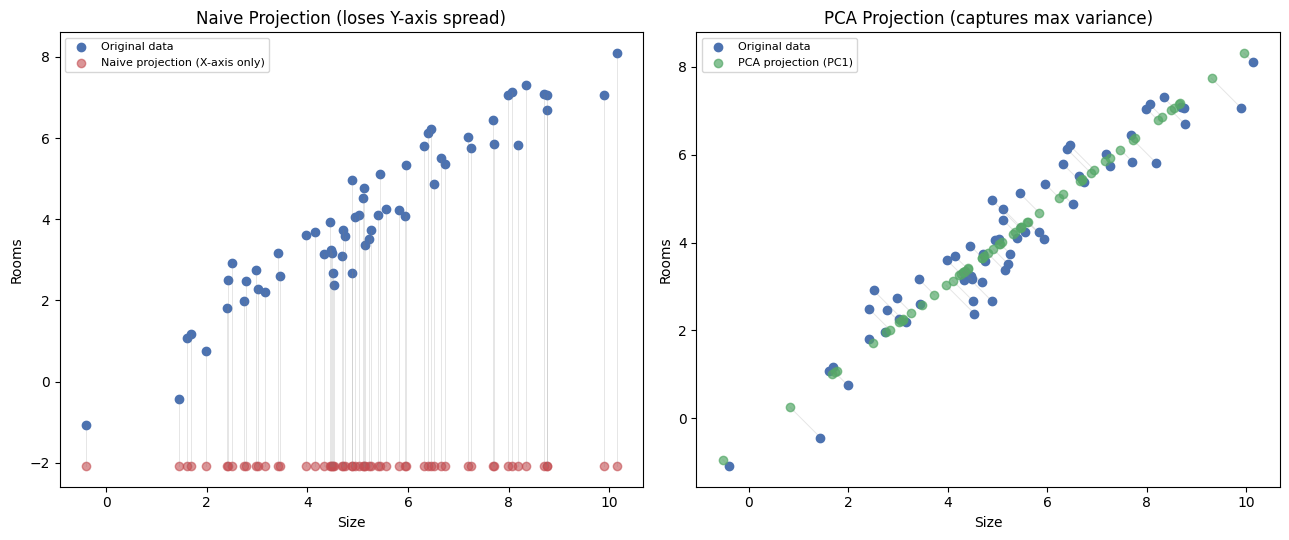

Variance retained by naive X-axis-only view: 55.9%
Variance retained by PCA's PC1:               97.8%


In [5]:
# ============================================================
# SIMULATE CORRELATED 2D DATA
# ============================================================

# Number of data points we want to generate.
#
# n = 60 means:
# 60 observations / data points
n = 60


# Generate random values representing the "Size" of houses.
#
# np.random.normal(mean, standard_deviation, number_of_values)
#
# mean = 5
# → Average house size will be around 5.
#
# standard deviation = 2
# → Controls how spread out the house sizes are.
#
# n = 60
# → Generate 60 house-size values.
size = np.random.normal(5, 2, n)


# Generate the "Number of Rooms" based on house size.
#
# 0.8 * size
# → Creates a positive relationship between Size and Rooms.
#
# As house size increases, the number of rooms tends
# to increase as well.
#
# np.random.normal(0, 0.6, n)
# → Adds some random noise to make the data more realistic.
#
# Therefore:
#
# Rooms ≈ 0.8 × Size + random noise
rooms = 0.8 * size + np.random.normal(0, 0.6, n)


# Combine Size and Rooms into one 2D dataset.
#
# column_stack() combines the two 1D arrays as columns.
#
# Result:
#
# X_2d =
#
#     Size    Rooms
#     -----   -----
#     ...      ...
#     ...      ...
#
# Shape:
# (60, 2)
#
# 60 observations
# 2 features
X_2d = np.column_stack([size, rooms])


# ============================================================
# NAIVE PROJECTION
# ============================================================

# A naive approach would be:
#
# "Let's simply keep the X-axis (Size)
#  and throw away the Rooms feature."
#
# This is NOT PCA.
#
# We are doing this only so that we can compare
# a simple projection with PCA.
naive_projection = X_2d.copy()


# Set the second feature (Rooms) to the same value
# for every data point.
#
# This visually collapses all points onto a horizontal line.
#
# X_2d[:, 1]
# → Selects the second column (Rooms).
#
# X_2d[:, 1].min()
# → Finds the smallest Rooms value.
#
# - 1
# → Moves the visualization line slightly below
#   the original data.
naive_projection[:, 1] = X_2d[:, 1].min() - 1


# ============================================================
# PCA PROJECTION
# ============================================================

# Create our PCA object.
#
# n_components=2 means we calculate both:
#
# PC1
# PC2
#
# standardize=False means:
# Do not scale the features to unit variance.
# The data will still be centered by our PCA implementation.
pca_2d = PCAFromScratch(
    n_components=2
).fit(
    X_2d,
    standardize=False
)


# Extract the first Principal Component direction.
#
# components_[0]
# → The first row contains PC1.
#
# PC1 is the direction in which the data
# has the maximum variance.
pc1_direction = pca_2d.components_[0]


# Calculate the mean point of the dataset.
#
# This gives us the center of the data:
#
# [mean Size, mean Rooms]
#
# PCA projection is performed around this mean point.
mean_point = X_2d.mean(axis=0)


# ============================================================
# PROJECT EACH DATA POINT ONTO PC1
# ============================================================

# First center every data point around the mean.
#
# X_2d - mean_point
#
# moves the center of the dataset to (0, 0).
#
# Then:
#
# @ pc1_direction
#
# calculates the dot product between each centered
# data point and the PC1 direction.
#
# The result is a scalar value representing
# the position of each point along PC1.
scalar_proj = (
    X_2d - mean_point
) @ pc1_direction


# Convert the 1D scalar projections back into
# 2D coordinates along the PC1 direction.
#
# np.outer() creates the coordinates along PC1.
#
# Finally, we add mean_point to move the projected
# points back to the original coordinate system.
#
# Result:
#
# pca_projected_points
# → Location of every data point after projection
#   onto the PC1 line.
pca_projected_points = (
    mean_point
    + np.outer(
        scalar_proj,
        pc1_direction
    )
)


# ============================================================
# CREATE TWO SIDE-BY-SIDE PLOTS
# ============================================================

# Create a figure containing two plots.
#
# 1 row
# 2 columns
#
# figsize controls the size of the entire figure.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5)
)


# ============================================================
# LEFT PLOT — NAIVE PROJECTION
# ============================================================

# Plot the original data points.
#
# X-axis → Size
# Y-axis → Rooms
axes[0].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    color="#4C72B0",
    label="Original data"
)


# Plot the naive projected points.
#
# Since we set all Rooms values to the same value,
# these points appear on a horizontal line.
axes[0].scatter(
    naive_projection[:, 0],
    naive_projection[:, 1],
    color="#C44E52",
    alpha=0.6,
    label="Naive projection (X-axis only)"
)


# Draw a line from every original point
# to its naive projected point.
#
# This visually shows the information that was lost
# when we removed the Rooms dimension.
for i in range(n):

    axes[0].plot(
        [
            X_2d[i, 0],
            naive_projection[i, 0]
        ],
        [
            X_2d[i, 1],
            naive_projection[i, 1]
        ],
        color="gray",
        alpha=0.2,
        linewidth=0.7
    )


# Add title to the left plot.
axes[0].set_title(
    "Naive Projection (loses Y-axis spread)"
)


# Label the X-axis.
axes[0].set_xlabel("Size")


# Label the Y-axis.
axes[0].set_ylabel("Rooms")


# Display the legend.
axes[0].legend(fontsize=8)


# ============================================================
# RIGHT PLOT — PCA PROJECTION
# ============================================================

# Plot the original data points again.
axes[1].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    color="#4C72B0",
    label="Original data"
)


# Plot the points projected onto PC1.
#
# These points lie along the direction
# that captures the maximum variance.
axes[1].scatter(
    pca_projected_points[:, 0],
    pca_projected_points[:, 1],
    color="#55A868",
    alpha=0.7,
    label="PCA projection (PC1)"
)


# Draw a line from each original point
# to its PCA-projected point.
#
# This helps us visually understand
# how each point is projected onto PC1.
for i in range(n):

    axes[1].plot(
        [
            X_2d[i, 0],
            pca_projected_points[i, 0]
        ],
        [
            X_2d[i, 1],
            pca_projected_points[i, 1]
        ],
        color="gray",
        alpha=0.2,
        linewidth=0.7
    )


# Add title to the PCA plot.
axes[1].set_title(
    "PCA Projection (captures max variance)"
)


# Label the X-axis.
axes[1].set_xlabel("Size")


# Label the Y-axis.
axes[1].set_ylabel("Rooms")


# Display the legend.
axes[1].legend(fontsize=8)


# Automatically adjust spacing between the plots
# so that labels and titles don't overlap.
plt.tight_layout()


# Display the final figure.
plt.show()


# ============================================================
# QUANTIFY THE INFORMATION LOSS
# ============================================================

# Calculate how much variance is retained by
# the naive X-axis-only projection.
#
# np.var(naive_projection[:, 0])
# → Variance of the Size feature.
#
# The denominator:
#
# np.var(X_2d[:, 0]) + np.var(X_2d[:, 1])
#
# represents the total variance across the two features.
#
# Therefore:
#
# variance retained =
# variance kept by naive projection
# ---------------------------------
# total original variance
naive_var_retained = (
    np.var(naive_projection[:, 0])
    /
    (
        np.var(X_2d[:, 0])
        +
        np.var(X_2d[:, 1])
    )
)


# Get the variance ratio captured by PC1.
#
# explained_variance_ratio_[0]
# → Explained variance ratio of PC1.
#
# Since PC1 is the direction with maximum variance,
# this tells us how much of the total variance
# is retained when projecting onto PC1.
pca_var_retained = (
    pca_2d.explained_variance_ratio_[0]
)


# ============================================================
# PRINT THE RESULTS
# ============================================================

# Print the percentage of variance retained
# by the naive X-axis-only approach.
#
# *100 converts the ratio into a percentage.
#
# :.1f means display one decimal place.
print(
    f"Variance retained by naive X-axis-only view: "
    f"{naive_var_retained * 100:.1f}%"
)


# Print the percentage of variance retained
# by PCA's first Principal Component.
print(
    f"Variance retained by PCA's PC1:               "
    f"{pca_var_retained * 100:.1f}%"
)

## B.2 PCA on the Iris Dataset (4D → 2D)

The classic Iris dataset has 4 features (sepal length/width, petal length/width) across 3 flower species.
We can't visualize 4 dimensions directly — let's use PCA to reduce it to 2D and see if the species still
separate cleanly.

In [6]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

print("Original shape:", X_iris.shape)
print("Features:", feature_names)


Original shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
# ============================================================
# STANDARDIZE THE IRIS DATA
# ============================================================

# Create a StandardScaler object from scikit-learn.
#
# StandardScaler standardizes each feature using:
#
#        X - mean
# Z =  --------------
#       standard deviation
#
# After standardization:
# Mean ≈ 0
# Standard deviation ≈ 1
scaler = StandardScaler()


# Fit the scaler on X_iris and transform the data.
#
# fit()
# → Calculates the mean and standard deviation
#   of each Iris feature.
#
# transform()
# → Uses those values to standardize X_iris.
#
# X_iris_scaled contains the standardized Iris data.
X_iris_scaled = scaler.fit_transform(X_iris)


# ============================================================
# APPLY OUR FROM-SCRATCH PCA
# ============================================================

# Create our PCAFromScratch object.
#
# n_components=2 means:
#
# We want to reduce the Iris dataset to:
#
# PC1
# PC2
#
# The Iris dataset originally has 4 features,
# so this reduces:
#
# 4 features → 2 Principal Components
pca_iris = PCAFromScratch(
    n_components=2
).fit(
    X_iris,
    standardize=True
)


# Transform the Iris data into the new
# Principal Component coordinate system.
#
# Since standardize=True:
#
# 1. Subtract the mean
# 2. Divide by standard deviation
# 3. Project the data onto PC1 and PC2
#
# Result:
#
# X_iris_pca.shape
# → (number_of_samples, 2)
#
# For Iris:
#
# 150 samples × 2 Principal Components
X_iris_pca = pca_iris.transform(
    X_iris,
    standardize=True
)


# ============================================================
# DISPLAY EXPLAINED VARIANCE
# ============================================================

# Print the explained variance ratio of PC1 and PC2.
#
# explained_variance_ratio_
# → Tells us what percentage of the total variance
#   is captured by each Principal Component.
#
# np.round(..., 4)
# → Round the values to 4 decimal places.
#
# Example:
#
# [0.7296, 0.2285]
#
# means:
#
# PC1 → 72.96% of variance
# PC2 → 22.85% of variance
print(
    "Explained variance ratio (PC1, PC2):",
    np.round(
        pca_iris.explained_variance_ratio_,
        4
    )
)


# Calculate the total variance captured
# by PC1 + PC2.
#
# .sum()
# → Adds the explained variance ratios.
#
# * 100
# → Converts the ratio into a percentage.
#
# :.1f
# → Display only one decimal place.
#
# Example:
#
# PC1 = 72.96%
# PC2 = 22.85%
#
# Total = 95.81%
#
# This means that although we reduced:
#
# 4 features → 2 features
#
# we still retained approximately 95.8%
# of the variance in the original dataset.
print(
    f"Total variance captured by 2 components: "
    f"{pca_iris.explained_variance_ratio_.sum() * 100:.1f}%"
)


Explained variance ratio (PC1, PC2): [0.7296 0.2285]
Total variance captured by 2 components: 95.8%


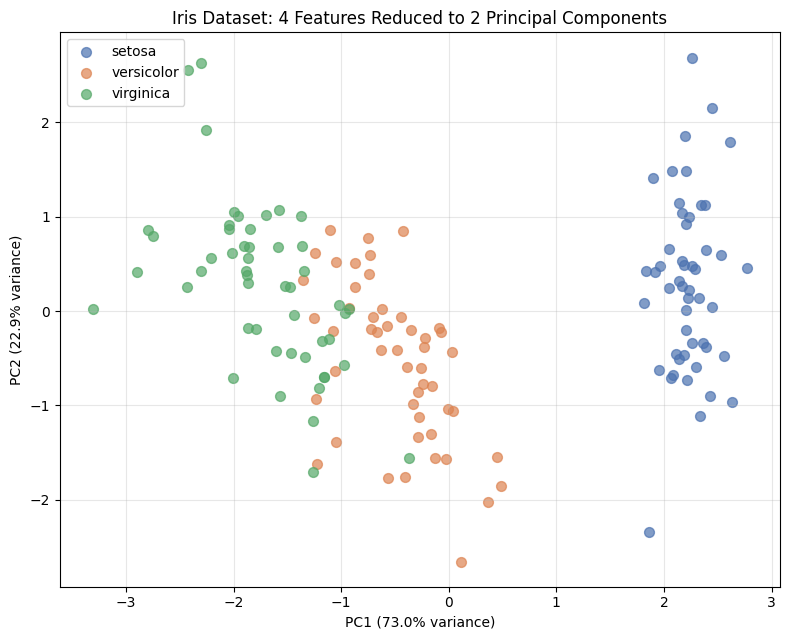

In [10]:
fig, ax = plt.subplots(figsize=(8, 6.5))
colors = ["#4C72B0", "#DD8452", "#55A868"]
for i, name in enumerate(target_names):
    mask = y_iris == i
    ax.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], label=name, color=colors[i], alpha=0.7, s=50)

ax.set_xlabel(f"PC1 ({pca_iris.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_iris.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Iris Dataset: 4 Features Reduced to 2 Principal Components")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:** Even after reducing from 4 dimensions to just 2, the three species form clearly
separable clusters — showing that most of the *useful* information (the variance that actually
distinguishes the species) was concentrated in just 2 principal components.

## B.3 Explained Variance / Scree Plot — How Many Components to Keep?

A **scree plot** shows how much variance each additional principal component captures — helping decide
where "diminishing returns" kick in.

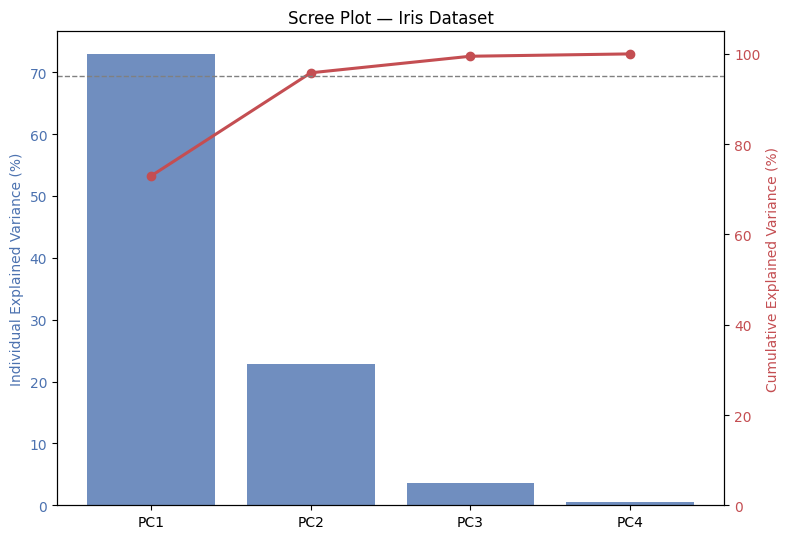

Number of components needed to capture >=95% variance: 2
Cumulative variance per component: [ 72.96  95.81  99.48 100.  ]


In [8]:
# ============================================================
# FIT PCA WITH ALL 4 COMPONENTS
# ============================================================

# The Iris dataset has 4 original features.
#
# Here we create PCA with n_components=4 so that
# we calculate all 4 Principal Components:
#
# PC1
# PC2
# PC3
# PC4
#
# standardize=True means the features are first
# centered and scaled before applying PCA.
pca_iris_full = PCAFromScratch(
    n_components=4
).fit(
    X_iris,
    standardize=True
)


# ============================================================
# INDIVIDUAL EXPLAINED VARIANCE
# ============================================================

# Get the explained variance ratio of each
# individual Principal Component.
#
# Example:
#
# PC1 → 72%
# PC2 → 23%
# PC3 → 4%
# PC4 → 1%
#
# These values tell us how much variance
# each component captures individually.
individual_variance = pca_iris_full.explained_variance_ratio_


# ============================================================
# CUMULATIVE EXPLAINED VARIANCE
# ============================================================

# np.cumsum() calculates the cumulative sum.
#
# Example:
#
# Individual variance:
# [72%, 23%, 4%, 1%]
#
# Cumulative variance:
# PC1 → 72%
# PC2 → 95%
# PC3 → 99%
# PC4 → 100%
#
# This helps us decide how many components
# we need to retain a certain amount of variance.
cumulative_variance = np.cumsum(individual_variance)


# ============================================================
# CREATE THE PLOT
# ============================================================

# Create a figure and the first Y-axis.
#
# figsize=(8, 5.5)
# → Controls the size of the plot.
fig, ax1 = plt.subplots(
    figsize=(8, 5.5)
)


# Create labels for the Principal Components.
#
# len(individual_variance) = 4
#
# Therefore:
#
# ["PC1", "PC2", "PC3", "PC4"]
x_labels = [
    f"PC{i+1}"
    for i in range(len(individual_variance))
]


# ============================================================
# BAR CHART — INDIVIDUAL VARIANCE
# ============================================================

# Create a bar chart showing the variance
# explained by EACH individual component.
#
# individual_variance contains values such as:
#
# [0.72, 0.23, 0.04, 0.01]
#
# * 100 converts them into percentages:
#
# [72, 23, 4, 1]
ax1.bar(
    x_labels,
    individual_variance * 100,
    color="#4C72B0",
    alpha=0.8,
    label="Individual variance"
)


# Label the Y-axis of the bar chart.
ax1.set_ylabel(
    "Individual Explained Variance (%)",
    color="#4C72B0"
)


# Change the color of the Y-axis tick labels
# to match the individual variance bars.
ax1.tick_params(
    axis="y",
    labelcolor="#4C72B0"
)


# ============================================================
# CREATE SECOND Y-AXIS
# ============================================================

# Create a second Y-axis sharing the same X-axis.
#
# We need two Y-axes because we are displaying:
#
# 1. Individual variance → bars
# 2. Cumulative variance → line
#
# Both use percentages but represent different things.
ax2 = ax1.twinx()


# ============================================================
# LINE CHART — CUMULATIVE VARIANCE
# ============================================================

# Plot cumulative explained variance.
#
# cumulative_variance might be:
#
# [0.72, 0.95, 0.99, 1.00]
#
# * 100 converts it into:
#
# [72, 95, 99, 100]
#
# marker="o"
# → Put a circle on each component.
#
# linewidth=2.2
# → Controls the thickness of the line.
ax2.plot(
    x_labels,
    cumulative_variance * 100,
    color="#C44E52",
    marker="o",
    linewidth=2.2,
    label="Cumulative variance"
)


# ============================================================
# ADD 95% THRESHOLD LINE
# ============================================================

# Draw a horizontal line at 95%.
#
# This represents our target:
#
# "We want to retain at least 95%
#  of the original variance."
#
# linestyle="--"
# → Dashed line.
ax2.axhline(
    95,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="95% threshold"
)


# Label the second Y-axis.
ax2.set_ylabel(
    "Cumulative Explained Variance (%)",
    color="#C44E52"
)


# Change the color of the second Y-axis
# tick labels to match the cumulative line.
ax2.tick_params(
    axis="y",
    labelcolor="#C44E52"
)


# Set the limits of the second Y-axis.
#
# 0  → Start at 0%
# 105 → End at 105%
#
# We use 105 instead of 100 so that the line
# and labels have a little extra space.
ax2.set_ylim(
    0,
    105
)


# ============================================================
# PLOT TITLE
# ============================================================

# Add a title to the complete plot.
plt.title(
    "Scree Plot — Iris Dataset"
)


# Automatically adjust the spacing so that
# labels and the plot don't overlap.
fig.tight_layout()


# Display the plot.
plt.show()


# ============================================================
# FIND NUMBER OF COMPONENTS REQUIRED FOR 95% VARIANCE
# ============================================================

# Find the first Principal Component where
# cumulative variance becomes >= 95%.
#
# Example:
#
# cumulative_variance:
#
# PC1 → 72%
# PC2 → 95%
# PC3 → 99%
# PC4 → 100%
#
# cumulative_variance >= 0.95 gives:
#
# [False, True, True, True]
#
# np.argmax() finds the first True position:
#
# index = 1
#
# But Python indexing starts from 0.
# Therefore, we add +1:
#
# 1 + 1 = 2
#
# So we need 2 components.
n_components_95 = (
    np.argmax(
        cumulative_variance >= 0.95
    ) + 1
)


# Print the number of Principal Components
# required to retain at least 95% variance.
print(
    f"Number of components needed to capture >=95% variance: "
    f"{n_components_95}"
)


# ============================================================
# DISPLAY CUMULATIVE VARIANCE
# ============================================================

# Print the cumulative variance after each
# Principal Component.
#
# * 100 converts the ratios into percentages.
#
# np.round(..., 2)
# → Round to 2 decimal places.
#
# Example:
#
# [72.96, 95.81, 98.91, 100.00]
print(
    "Cumulative variance per component:",
    np.round(
        cumulative_variance * 100,
        2
    )
)

## 📊 Observations from the Scree Plot

1. **PC1 explains the largest amount of variance**, approximately **73%**.
   - This means PC1 captures most of the information present in the Iris dataset.

2. **PC2 explains approximately 23%** of the variance.
   - PC2 captures additional information that is not captured by PC1.

3. **PC1 + PC2 capture approximately 96% of the total variance**.
   - Therefore, we can reduce the Iris dataset from **4 features to 2 principal components** while retaining about **96% of the variance**.

4. **PC3 contributes only around 4%** additional variance.
   - Its contribution is relatively small compared with PC1 and PC2.

5. **PC4 contributes less than 1%** of the variance.
   - It contains very little additional information.

6. The **cumulative variance curve becomes almost flat after PC2**.
   - Adding PC3 and PC4 provides only a small improvement.

7. The cumulative variance **crosses the 95% threshold at PC2**.
   - Therefore, **2 principal components are sufficient to capture at least 95% of the variance**.

### 🎯 Conclusion

> Based on the Scree Plot, **PC1 and PC2 together explain approximately 96% of the total variance**. Therefore, we can reduce the Iris dataset from **4 dimensions to 2 dimensions** while preserving most of the information. PC3 and PC4 contribute relatively little additional variance and can be discarded for dimensionality reduction.

## B.4 Image Compression Demo — PCA on the Digits Dataset

Each image in the Digits dataset is an 8x8 grid of pixels (64 features). We'll use PCA to compress each
image down to far fewer components, then reconstruct it — visualizing how much detail is preserved at
different compression levels.

Original shape: (1797, 64) -> each image is a 64-length vector (8x8 pixels)


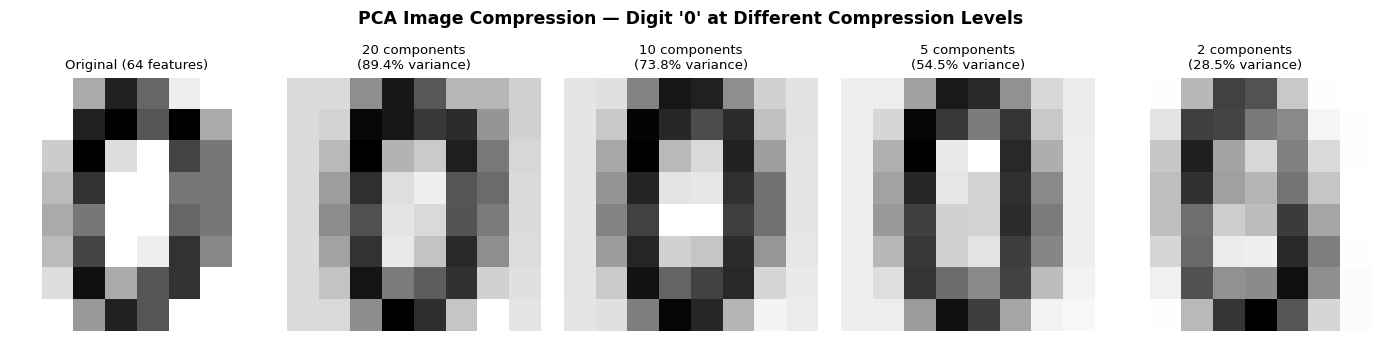

In [9]:
# ============================================================
# B.4 IMAGE COMPRESSION DEMO — PCA ON THE DIGITS DATASET
# ============================================================

# The Digits dataset contains small handwritten digit images.
#
# Each image is:
#
#     8 × 8 pixels
#
# Therefore:
#
#     8 × 8 = 64 pixels
#
# Each pixel becomes one feature.
#
# So every image is represented as:
#
#     64 features
#
# Example:
#
#     Original image
#          8 × 8
#            ↓
#     Flattened into
#          64 values
#
# PCA will reduce these 64 features into fewer
# Principal Components and then reconstruct the image.
digits = load_digits()


# Get the pixel data from the Digits dataset.
#
# X_digits contains all images as flattened vectors.
#
# Shape:
#
#     (1797, 64)
#
# 1797 → number of images
# 64   → number of pixels/features per image
X_digits = digits.data


# Display the original shape of the dataset.
#
# This confirms that every image is represented
# as a 64-dimensional vector.
print(
    "Original shape:",
    X_digits.shape,
    "-> each image is a 64-length vector (8x8 pixels)"
)


# ============================================================
# SELECT ONE IMAGE FOR VISUALIZATION
# ============================================================

# Select the first image from the dataset.
#
# X_digits[0] contains 64 pixel values.
#
# It represents one 8 × 8 handwritten digit image.
sample_image = X_digits[0]


# Get the actual digit/label corresponding to
# the selected image.
#
# For example:
#
# sample_label = 0
#
# means the selected image represents digit "0".
sample_label = digits.target[0]


# ============================================================
# CREATE SUBPLOTS
# ============================================================

# Create 5 plots side-by-side.
#
# Each plot will show the same digit but with
# a different number of PCA components.
#
# We will compare:
#
#     64 components → Original
#     20 components → Compressed
#     10 components → More compressed
#      5 components → Highly compressed
#      2 components → Very highly compressed
fig, axes = plt.subplots(
    1,
    5,
    figsize=(14, 3.2)
)


# Number of PCA components we want to test.
#
# 64 → No dimensionality reduction
# 20 → Keep only 20 dimensions
# 10 → Keep only 10 dimensions
#  5 → Keep only 5 dimensions
#  2 → Keep only 2 dimensions
component_counts = [64, 20, 10, 5, 2]


# ============================================================
# APPLY PCA WITH DIFFERENT COMPRESSION LEVELS
# ============================================================

# Loop through:
#
# ax → current subplot
# k  → number of PCA components
#
# zip() pairs the subplot with the corresponding
# component count.
for ax, k in zip(axes, component_counts):


    # --------------------------------------------------------
    # CASE 1: 64 COMPONENTS
    # --------------------------------------------------------

    # If we keep all 64 components,
    # we are not performing compression.
    if k == 64:

        # Use the original image directly.
        #
        # No PCA transformation is necessary because
        # we are keeping all 64 original dimensions.
        reconstructed = sample_image


        # Title for the original image.
        title = "Original (64 features)"


    # --------------------------------------------------------
    # CASE 2: PCA COMPRESSION
    # --------------------------------------------------------

    else:

        # Create a PCA model that keeps only k components.
        #
        # Example:
        #
        # k = 20
        #
        #     64 features
        #          ↓
        #         PCA
        #          ↓
        #     20 components
        #
        # This is dimensionality reduction.
        pca_k = SklearnPCA(
            n_components=k
        )


        # Transform ALL 1797 images into the
        # lower-dimensional PCA space.
        #
        # Original:
        #
        #     (1797, 64)
        #
        # After PCA with k=20:
        #
        #     (1797, 20)
        #
        # So each image is now represented using
        # only 20 numbers instead of 64.
        X_digits_pca = pca_k.fit_transform(
            X_digits
        )


        # Reconstruct the images from the reduced
        # PCA representation.
        #
        # inverse_transform() performs approximately:
        #
        #     PCA representation
        #             ↓
        #     Reconstruct original feature space
        #             ↓
        #          64 pixels
        #
        # For k=20:
        #
        #     20 components
        #          ↓
        #     reconstruction
        #          ↓
        #     64 pixel values
        reconstructed_all = pca_k.inverse_transform(
            X_digits_pca
        )


        # We only want to display the first image.
        #
        # reconstructed_all contains reconstructed versions
        # of all 1797 images.
        #
        # [0] selects the first reconstructed image.
        reconstructed = reconstructed_all[0]


        # Calculate how much variance is retained
        # by the selected k components.
        #
        # explained_variance_ratio_
        # → Variance explained by each component.
        #
        # .sum()
        # → Total variance explained by all selected components.
        #
        # * 100
        # → Convert ratio into percentage.
        variance_kept = (
            pca_k.explained_variance_ratio_.sum()
            * 100
        )


        # Create a title showing:
        #
        # Number of components
        # +
        # Percentage of variance retained
        #
        # Example:
        #
        # 20 components
        # (89.4% variance)
        title = (
            f"{k} components\n"
            f"({variance_kept:.1f}% variance)"
        )


    # ========================================================
    # DISPLAY THE IMAGE
    # ========================================================

    # The reconstructed image is currently a
    # 64-length vector.
    #
    # Example:
    #
    # [pixel1, pixel2, ..., pixel64]
    #
    # But an image needs a 2D shape:
    #
    #     8 × 8
    #
    # reshape(8, 8) converts the 64-length vector
    # back into an 8 × 8 image.
    ax.imshow(
        reconstructed.reshape(8, 8),
        cmap="gray_r"
    )


    # Add the title above each image.
    #
    # The title shows the compression level
    # and the percentage of variance retained.
    ax.set_title(
        title,
        fontsize=9.5
    )


    # Remove the X-axis and Y-axis.
    #
    # We don't need axis numbers because
    # we only want to visualize the digit.
    ax.axis("off")


# ============================================================
# ADD MAIN TITLE
# ============================================================

# Add a title above the complete figure.
#
# sample_label tells us which digit is being displayed.
#
# Example:
#
# PCA Image Compression — Digit '0'
plt.suptitle(
    f"PCA Image Compression — Digit '{sample_label}' "
    f"at Different Compression Levels",
    fontsize=12.5,
    fontweight="bold",
    y=1.05
)


# Automatically adjust spacing between the images
# and their titles.
plt.tight_layout()


# Display the final figure.
plt.show()

**Observation:** Even with just 10-20 components (down from 64 original pixel features), the digit
remains clearly recognizable — a real, visual demonstration of how PCA can dramatically reduce
dimensionality while preserving the essential information.

## 📊 Observations from the PCA Image Compression

1. **Original image uses 64 features** because each digit image is an **8 × 8 pixel grid**.

2. With **20 PCA components**, about **89.4% of the variance is retained**.
   - The reconstructed digit still looks very similar to the original.
   - This provides a good balance between compression and image quality.

3. With **10 components**, about **73.8% of the variance is retained**.
   - The digit is still recognizable, but some details are lost.
   - The image becomes slightly blurrier.

4. With **5 components**, about **54.5% of the variance is retained**.
   - More information is lost.
   - The reconstructed digit is still recognizable, but its shape becomes less clear.

5. With only **2 components**, about **28.5% of the variance is retained**.
   - Significant information is lost.
   - The reconstructed image is much less detailed, although the general shape of the digit can still be identified.

6. As the **number of PCA components decreases**, compression increases but **image quality decreases**.

### 🔄 PCA Compression Trade-off

```text
More Components
       ↓
Less Compression
       ↓
More Variance Retained
       ↓
Better Image Quality

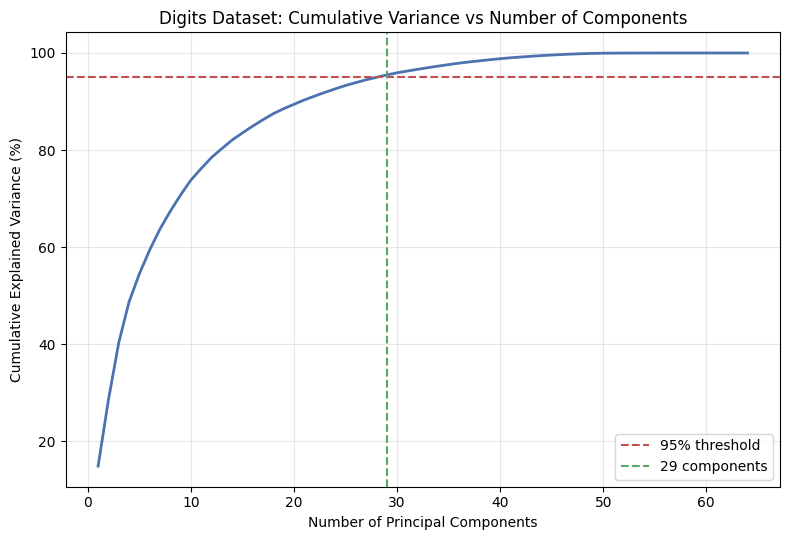

Original dimensions: 64
Components needed for 95% variance: 29
Compression ratio: 2.2x fewer dimensions, same ~95% information retained


In [10]:
# ============================================================
# FULL SCREE PLOT — DIGITS DATASET
# ============================================================
#
# Goal:
# Find out how many Principal Components are required
# to retain at least 95% of the variance in the Digits dataset.
#
# Original dataset:
#
#     1797 images × 64 features
#
# Each image is an 8 × 8 image:
#
#     8 × 8 = 64 features
#
# We want to find:
#
#     "Can we reduce these 64 dimensions while
#      keeping at least 95% of the variance?"
# ============================================================


# Create a PCA object using scikit-learn.
#
# No n_components is specified, so PCA calculates
# all possible Principal Components.
#
# Since the Digits dataset has 64 features,
# PCA can produce up to 64 components.
#
# fit(X_digits)
# → Learns the Principal Components from the dataset.
pca_digits_full = SklearnPCA().fit(X_digits)


# Get the explained variance ratio of every
# Principal Component.
#
# explained_variance_ratio_ tells us how much
# variance is explained by EACH component.
#
# Example:
#
# PC1 → 14%
# PC2 → 13%
# PC3 → 11%
# ...
cum_var_digits = np.cumsum(
    pca_digits_full.explained_variance_ratio_
)


# ============================================================
# FIND NUMBER OF COMPONENTS REQUIRED FOR 95% VARIANCE
# ============================================================

# Check where the cumulative explained variance
# first becomes greater than or equal to 95%.
#
# Example:
#
# Cumulative variance:
#
# PC1 → 14%
# PC2 → 26%
# PC3 → 36%
# ...
# PC40 → 94%
# PC41 → 95.2%  ← first point >= 95%
#
# np.argmax() finds the index of the first True value.
#
# Since Python uses zero-based indexing,
# we add +1 to get the actual component number.
n_components_95_digits = np.argmax(
    cum_var_digits >= 0.95
) + 1


# ============================================================
# CREATE THE SCREE / CUMULATIVE VARIANCE PLOT
# ============================================================

# Create a figure and axes for the plot.
fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


# Plot cumulative explained variance.
#
# X-axis:
#     Number of Principal Components
#
# Y-axis:
#     Cumulative Explained Variance (%)
#
# cum_var_digits contains values between 0 and 1.
#
# Multiplying by 100 converts them to percentages.
#
# Example:
#
# 0.95 → 95%
ax.plot(
    range(1, len(cum_var_digits) + 1),
    cum_var_digits * 100,
    color="#4C72B0",
    linewidth=2
)


# Draw a horizontal line at 95%.
#
# This represents our target:
#
# "We want to retain at least 95% of the variance."
ax.axhline(
    95,
    color="#C44E52",
    linestyle="--",
    label="95% threshold"
)


# Draw a vertical line at the number of components
# required to reach 95% variance.
#
# For example, if:
#
# n_components_95_digits = 41
#
# then a vertical line will appear at PC41.
#
# This makes it easy to visually identify
# the required number of components.
ax.axvline(
    n_components_95_digits,
    color="#55A868",
    linestyle="--",
    label=f"{n_components_95_digits} components"
)


# Label the X-axis.
#
# It represents the number of Principal Components
# being retained.
ax.set_xlabel(
    "Number of Principal Components"
)


# Label the Y-axis.
#
# It represents the total percentage of variance
# retained as we add more components.
ax.set_ylabel(
    "Cumulative Explained Variance (%)"
)


# Add a title to the plot.
ax.set_title(
    "Digits Dataset: Cumulative Variance vs Number of Components"
)


# Display the legend.
#
# The legend explains:
#
# Blue line  → Cumulative variance
# Red line   → 95% threshold
# Green line → Required number of components
ax.legend()


# Add a light grid to make the graph easier to read.
ax.grid(
    alpha=0.3
)


# Automatically adjust spacing so that
# labels and the title don't overlap.
plt.tight_layout()


# Display the plot.
plt.show()


# ============================================================
# PRINT THE RESULTS
# ============================================================

# Print the original number of dimensions.
#
# Each image originally contains:
#
#     8 × 8 = 64 pixels
#
# Therefore:
#     64 dimensions/features
print(
    f"Original dimensions: 64"
)


# Print the number of Principal Components
# required to retain at least 95% variance.
print(
    f"Components needed for 95% variance: "
    f"{n_components_95_digits}"
)


# Calculate the compression ratio.
#
# Formula:
#
#     Original dimensions
#     -------------------
#     Reduced dimensions
#
# Example:
#
#     64 / 40 = 1.6
#
# This means the data uses approximately
# 1.6× fewer dimensions.
#
# The "~95% information retained" statement refers
# to retaining approximately 95% of the variance.
print(
    f"Compression ratio: "
    f"{64/n_components_95_digits:.1f}x fewer dimensions, "
    f"same ~95% information retained"
)

## 📊 Observations from the Digits Dataset PCA Plot

1. The original Digits dataset contains **64 features** because each image is an **8 × 8 pixel image**.

2. The cumulative explained variance increases rapidly with the first few Principal Components.
   - The first few components capture a large amount of the total variance.

3. The curve reaches the **95% variance threshold at approximately 29 components**.
   - Therefore, **29 Principal Components are required to retain at least 95% of the variance**.

4. PCA reduces the dimensionality from:
   
   **64 features → 29 Principal Components**

5. This represents approximately a **2.2× reduction in dimensions**:

   ```text
   64 / 29 ≈ 2.2